In [1]:
# Import libraries for data loading, preprocessing, modeling, evaluation, and saving the model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

print("Baseline modeling environment ready")

Baseline modeling environment ready


In [2]:
# Load the processed modeling dataset created in the EDA notebook

path = "../data/processed/denial_risk_modeling_sample_250k.csv"

df = pd.read_csv(path)

print(df.shape)
df.head()

(250000, 24)


,provider_npi,provider_state,provider_type,medicare_participating,hcpcs_code,hcpcs_description,is_drug,place_of_service,total_beneficiaries,total_services,total_beneficiary_day_services,avg_submitted_charge,avg_medicare_allowed_amount,avg_medicare_payment_amount,avg_medicare_standardized_amount,charge_to_allowed_ratio,payment_to_charge_ratio,payment_to_allowed_ratio,services_per_beneficiary,high_charge_allowed_ratio,low_payment_charge_ratio,high_service_intensity,risk_score,denial_risk_proxy
0,1003882531,UT,Family Practice,Y,77067,Screening mammography,N,O,11,11.0,11,325.660000,84.184545,84.184545,90.226364,3.868406,0.258504,1.000000,1.000000,0,0,0,0,0
1,1992254726,TX,Nurse Practitioner,Y,87804,Detection test by immunoassay with direct visu...,N,O,11,11.0,11,50.000000,16.220000,16.220000,16.220000,3.082614,0.324400,1.000000,1.000000,0,0,0,0,0
2,1750657938,PA,Emergency Medicine,Y,99285,Emergency department visit with high level of ...,N,F,51,51.0,51,1377.980392,172.981765,133.733333,130.515294,7.966044,0.097050,0.773107,1.000000,1,1,0,2,1
3,1205611712,FL,Nurse Practitioner,Y,99350,Residence visit for established patient with h...,N,O,56,75.0,75,180.900000,154.000000,122.700000,122.450000,1.174675,0.678275,0.796753,1.339286,0,0,0,0,0
4,1023763927,MD,Physical Therapist in Private Practice,Y,97110,Therapy procedure using exercise to develop st...,N,O,77,917.0,811,75.000000,28.049662,21.247874,19.097012,2.673829,0.283305,0.757509,11.909091,0,0,1,1,0


In [ ]:
# check how many low risk/ high risk 
df["denial_risk_proxy"].value_counts()

denial_risk_proxy
0    190698
1     59302
Name: count, dtype: int64

In [4]:
# Check the percentage split for the proxy denial-risk label

df["denial_risk_proxy"].value_counts(normalize=True)

denial_risk_proxy
0    0.762792
1    0.237208
Name: proportion, dtype: float64

In [5]:
# Select useful features for the first baseline model and define the target variable

features = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "is_drug",
    "place_of_service",
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "payment_to_allowed_ratio",
    "services_per_beneficiary"
]

target = "denial_risk_proxy"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(250000, 17)
(250000,)


In [9]:
# Separate categorical and numeric columns so each type can be preprocessed correctly

categorical_features = [
    "provider_state",
    "provider_type",
    "medicare_participating",
    "hcpcs_code",
    "is_drug",
    "place_of_service"
]

numeric_features = [
    "total_beneficiaries",
    "total_services",
    "total_beneficiary_day_services",
    "avg_submitted_charge",
    "avg_medicare_allowed_amount",
    "avg_medicare_payment_amount",
    "avg_medicare_standardized_amount",
    "charge_to_allowed_ratio",
    "payment_to_charge_ratio",
    "payment_to_allowed_ratio",
    "services_per_beneficiary"
]

print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Categorical features: 6
Numeric features: 11


In [7]:
# Split the data into training and test sets while preserving the target class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(200000, 17)
(50000, 17)
denial_risk_proxy
0    0.76279
1    0.23721
Name: proportion, dtype: float64
denial_risk_proxy
0    0.7628
1    0.2372
Name: proportion, dtype: float64


In [10]:
# Build a modeling pipeline that one-hot encodes categorical columns and trains a Random Forest model

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Train the baseline Random Forest model on the training data

pipeline.fit(X_train, y_train)

print("Model training complete")

Model training complete


In [12]:
# Generate class predictions and probability scores on the test set

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Predictions complete")

Predictions complete


In [13]:
# Evaluate the baseline model using classification metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

Accuracy:  0.9832
Precision: 0.9496
Recall:    0.9811
F1 Score:  0.9651
ROC AUC:   0.9987


In [14]:
# Display a detailed classification report for low-risk and high-risk classes

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     38140
           1       0.95      0.98      0.97     11860

    accuracy                           0.98     50000
   macro avg       0.97      0.98      0.98     50000
weighted avg       0.98      0.98      0.98     50000



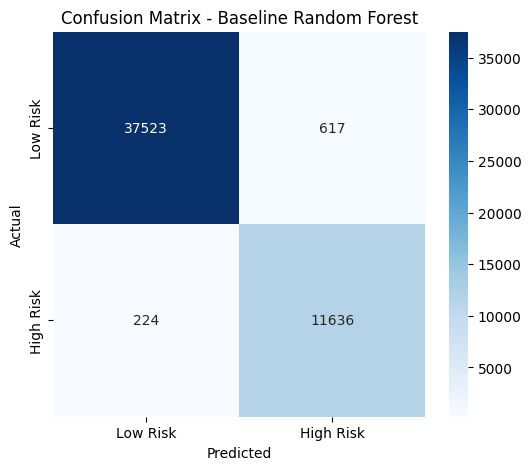

In [15]:
# Plot the confusion matrix to compare correct and incorrect predictions

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"]
)

plt.title("Confusion Matrix - Baseline Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# Extract feature names after one-hot encoding so feature importance can be interpreted

cat_feature_names = pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)

all_feature_names = list(cat_feature_names) + numeric_features

len(all_feature_names)

3383

In [17]:
# Create a feature importance dataframe from the trained Random Forest model

importances = pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
3379,charge_to_allowed_ratio,0.244868
3380,payment_to_charge_ratio,0.216024
3370,place_of_service_F,0.071827
3375,avg_submitted_charge,0.069752
3371,place_of_service_O,0.062991
67,provider_type_Anesthesiology,0.031284
3376,avg_medicare_allowed_amount,0.025181
3378,avg_medicare_standardized_amount,0.024973
84,provider_type_Diagnostic Radiology,0.020086
3377,avg_medicare_payment_amount,0.014833


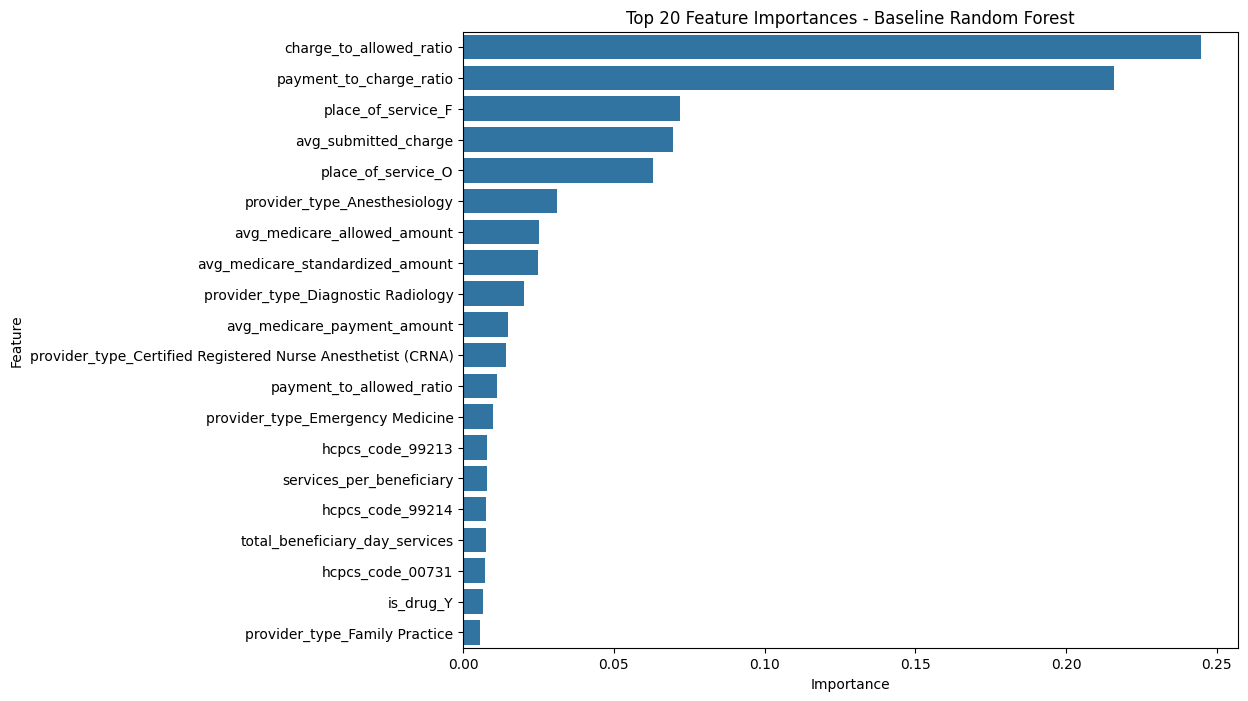

In [18]:
# Plot the top 20 most important features from the baseline model

top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances - Baseline Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
# Save the trained pipeline so it can be reused later in the Streamlit app or FastAPI endpoint

model_path = "../models/baseline_random_forest_denial_risk_model.joblib"

joblib.dump(pipeline, model_path)

print(f"Model saved to {model_path}")

Model saved to ../models/baseline_random_forest_denial_risk_model.joblib


In [20]:
# Save feature importance results for reporting and documentation

feature_importance_df.to_csv("../reports/baseline_feature_importance.csv", index=False)

print("Feature importance saved successfully")

Feature importance saved successfully


In [21]:
# Save test-set predictions for later error analysis

predictions_df = X_test.copy()
predictions_df["actual_denial_risk_proxy"] = y_test.values
predictions_df["predicted_denial_risk_proxy"] = y_pred
predictions_df["predicted_high_risk_probability"] = y_proba

predictions_df.to_csv("../reports/baseline_test_predictions.csv", index=False)

print("Test predictions saved successfully")

Test predictions saved successfully


# Baseline Denial-Risk Modeling

This notebook trains a baseline machine learning model to predict the engineered proxy denial-risk label.

The target is not a true claim denial outcome. It is a proxy label created from reimbursement friction signals, including high charge-to-allowed ratio, low payment-to-charge ratio, and high service intensity.

The goal of this notebook is to prove that the workflow can move from CMS reimbursement data to a working risk-scoring model.